# Download the dataset from Kaggle

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
# download in /content
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:03<00:00, 8.29MB/s]



In [3]:
# to unzip
!unzip /content/imdb-dataset-of-50k-movie-reviews.zip

Archive:  /content/imdb-dataset-of-50k-movie-reviews.zip
  inflating: IMDB Dataset.csv        


# Required Libaries

In [4]:
import pandas as pd
import numpy as np
import nltk

# Load the dataset

In [5]:
# On google colab
data = pd.read_csv('/content/IMDB Dataset.csv')

# On project folder
data = pd.read_csv('./data/raw/IMDB Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
# look single row
data['review'][1]

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [7]:
data.shape

(50000, 2)

In [8]:
# Overview of dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
# Check the target column distribution
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [10]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


# Cleaning the Text

In [11]:
# In single rows
data['review'][37416]

'As you know "The Greatest Game Ever Played" is about golf. I used to snicker at the over-dramatic title, but through great visual display credited to director Bill Paxton (better known for his acting in Twister and hilarious supporting roles in Aliens and True Lies) we find out that this has much more meaning than a game.<br /><br />Though the movie is about golf, it seems as though the sport is just the framework for what is really going on. What is really going on is a story of individuals being told they can\'t fulfill their dreams, be it age or social status. A conflict between a son\'s wishes and a father\'s demands. An English golf legend looking to bring the title home with the country breathing down his neck.<br /><br />Shia LaBeouf (Even Stevens) plays Francis Ouimet, a caddy with a God-given talent who was never permitted to play golf in the first place. Despite the resentment of the upper class "gentlemen," it was undeniable that Francis had a gift. What posed a greater thr

###  Applying Lowercase

In [12]:
data['review'][37416].lower()

'as you know "the greatest game ever played" is about golf. i used to snicker at the over-dramatic title, but through great visual display credited to director bill paxton (better known for his acting in twister and hilarious supporting roles in aliens and true lies) we find out that this has much more meaning than a game.<br /><br />though the movie is about golf, it seems as though the sport is just the framework for what is really going on. what is really going on is a story of individuals being told they can\'t fulfill their dreams, be it age or social status. a conflict between a son\'s wishes and a father\'s demands. an english golf legend looking to bring the title home with the country breathing down his neck.<br /><br />shia labeouf (even stevens) plays francis ouimet, a caddy with a god-given talent who was never permitted to play golf in the first place. despite the resentment of the upper class "gentlemen," it was undeniable that francis had a gift. what posed a greater thr

In [13]:
# On entire df
data['review'] = data['review'].str.lower()
data.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


### Remove HTML Tags

In [14]:
import re

def remove_html_tags(text):
  pattern = re.compile('<.*?>')
  return pattern.sub(r'', text)

In [15]:
text = "<html><body><p> Movie 1</p><p> Actor - Aamir Khan</p><p> Click here to <a href='http://google.com'>download</a></p>"

In [16]:
remove_html_tags(text)

' Movie 1 Actor - Aamir Khan Click here to download'

In [17]:
# On entire df
data['review'] = data['review'].apply(remove_html_tags)

In [18]:
data['review'][37416].lower()

'as you know "the greatest game ever played" is about golf. i used to snicker at the over-dramatic title, but through great visual display credited to director bill paxton (better known for his acting in twister and hilarious supporting roles in aliens and true lies) we find out that this has much more meaning than a game.though the movie is about golf, it seems as though the sport is just the framework for what is really going on. what is really going on is a story of individuals being told they can\'t fulfill their dreams, be it age or social status. a conflict between a son\'s wishes and a father\'s demands. an english golf legend looking to bring the title home with the country breathing down his neck.shia labeouf (even stevens) plays francis ouimet, a caddy with a god-given talent who was never permitted to play golf in the first place. despite the resentment of the upper class "gentlemen," it was undeniable that francis had a gift. what posed a greater threat was the discourageme

### Handling Non-ASCII

In [19]:
def clean_non_ascii(text):
    # Remove non-ASCII but preserve word boundaries
    ascii_only = text.encode("ascii", "ignore").decode()

    # Fix any accidental word merges
    return re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', ascii_only)

In [20]:
text1 = 'Price\x96$100\x68Total\xb34'
text2 = "I love this! 😍🎉"
text3 = "Hello 世界 World こんにちは"

In [21]:
clean_non_ascii(text1)

'Price$100h Total4'

In [22]:
# On entire df
data['review'] = data['review'].apply(clean_non_ascii)

### Remove Punctuation

In [23]:
import string,time
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [24]:
exclude = string.punctuation

def remove_punc(text):
  for char in exclude:
    text = text.replace(char,'')
  return text

In [25]:
remove_punc(data['review'][37416].lower())

'as you know the greatest game ever played is about golf i used to snicker at the overdramatic title but through great visual display credited to director bill paxton better known for his acting in twister and hilarious supporting roles in aliens and true lies we find out that this has much more meaning than a gamethough the movie is about golf it seems as though the sport is just the framework for what is really going on what is really going on is a story of individuals being told they cant fulfill their dreams be it age or social status a conflict between a sons wishes and a fathers demands an english golf legend looking to bring the title home with the country breathing down his neckshia labeouf even stevens plays francis ouimet a caddy with a godgiven talent who was never permitted to play golf in the first place despite the resentment of the upper class gentlemen it was undeniable that francis had a gift what posed a greater threat was the discouragement of his father played by el

In [26]:
# On entire df
data['review'] = data['review'].apply(remove_punc)

### Spelling Correction(take too much time)

In [27]:
pip install pyspellchecker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 99.4 MB/s eta 0:00:00


In [28]:
from spellchecker import SpellChecker

spell = SpellChecker()

def spell_check(text):
    corrected_list = []

    words = text.split()
    # Only fix words that are actually misspelled
    misspelled = spell.unknown(words)
    for word in words:
        if word in misspelled:
            correction = spell.correction(word)
            # Use the correction if it exists, otherwise keep the original word
            corrected_list.append(correction if correction is not None else word)
        else:
            corrected_list.append(word)

    return " ".join(corrected_list)

In [29]:
text = 'ceertain conditionas during sveal ggenerations aree moodified in the saame manner.'

In [30]:
spell_check(data['review'][37416])

"as you know the greatest game ever played is about golf i used to snicker at the overdramatize title but through great visual display credited to director bill paxton better known for his acting in twister and hilarious supporting roles in aliens and true lies we find out that this has much more meaning than a gamethough the movie is about golf it seems as though the sport is just the framework for what is really going on what is really going on is a story of individuals being told they cant fulfill their dreams be it age or social status a conflict between a sons wishes and a fathers demands an english golf legend looking to bring the title home with the country breathing down his neckshia babeuf even stevens plays francis quiet a caddy with a forgiven talent who was never permitted to play golf in the first place despite the resentment of the upper class gentlemen it was undeniable that francis had a gift what posed a greater threat was the discouragement of his father played by eli

### Possible slang word

In [31]:
from spellchecker import SpellChecker

spell = SpellChecker()

def find_potential_slang(text_list):
    # Combine all reviews into one long list of words
    all_words = " ".join(text_list).split()

    # Find words that the spellchecker doesn't recognize
    unknown = spell.unknown(all_words)

    # Show the top 500 unrecognized words
    from collections import Counter
    return Counter([w for w in all_words if w in unknown]).most_common(500)

# Example usage:
print(find_potential_slang(data['review']))

[('dont', 16626), ('im', 9017), ('doesnt', 8881), ('didnt', 8795), ('thats', 7227), ('ive', 6451), ('isnt', 6287), ('theres', 5858), ('tv', 5315), ('dvd', 4563), ('wasnt', 4500), ('youre', 3816), ('couldnt', 3038), ('youll', 2604), ('theyre', 2449), ('wouldnt', 2103), ('etc', 2080), ('arent', 1718), ('havent', 1632), ('80s', 1457), ('youve', 1441), ('whos', 1389), ('scifi', 1292), ('imdb', 1263), ('70s', 1133), ('werent', 950), ('humour', 917), ('youd', 766), ('hasnt', 691), ('shouldnt', 677), ('ii', 677), ('clich', 647), ('cgi', 638), ('favourite', 619), ('todays', 611), ('clichs', 607), ('noir', 598), ('60s', 594), ('ie', 577), ('vhs', 557), ('hadnt', 541), ('lowbudget', 541), ('weve', 505), ('1950s', 480), ('theyve', 467), ('90s', 443), ('50s', 424), ('1970s', 423), ('uk', 422), ('bmovie', 402), ('bbc', 401), ('childrens', 389), ('clichd', 383), ('andor', 377), ('overthetop', 376), ('aint', 376), ('1980s', 374), ('seagal', 366), ('wouldve', 358), ('usa', 347), ('hed', 345), ('couldv

In [32]:
slang_map = {
    # Contractions (The most frequent in your list)
    "dont": "do not", "im": "i am", "doesnt": "does not", "didnt": "did not",
    "thats": "that is", "ive": "i have", "isnt": "is not", "theres": "there is",
    "wasnt": "was not", "youre": "you are", "couldnt": "could not", "youll": "you will",
    "theyre": "they are", "wouldnt": "would not", "arent": "are not", "havent": "have not",
    "youve": "you have", "whos": "who is", "werent": "were not", "youd": "you would",
    "hasnt": "has not", "shouldnt": "should not", "hadnt": "had not", "weve": "we have",
    "aint": "am not", "wouldve": "would have", "couldve": "could have", "theyd": "they would",
    "theyve": "they have", "theyll": "they will", "hed": "he would","cant":"can not",

    # Movie & Media Terms
    "tv": "television", "dvd": "digital video disc", "dvds": "digital video discs",
    "vhs": "video home system", "scifi": "science fiction", "cgi": "computer generated imagery",
    "imdb": "internet movie database", "noir": "film noir", "fx": "special effects",
    "bmovie": "b-movie", "mst3k": "mystery science theater", "hbo": "home box office",
    "fbi": "federal bureau of investigation", "cia": "central intelligence agency",
    "wwii": "world war two", "bbc": "british broadcasting corporation",

    # Decades & Time
    "80s": "eighties", "70s": "seventies", "60s": "sixties", "50s": "fifties",
    "40s": "forties", "30s": "thirties", "90s": "nineties", "1950s": "fifties",
    "1970s": "seventies", "1980s": "eighties", "1930s": "thirties", "1960s": "sixties",
    "20th": "twentieth", "1st": "first", "todays": "today is",

    # Common Errors/Misc (From your specific list)
    "clich": "cliche", "clichs": "cliches", "clichd": "cliche", "etc": "et cetera",
    "humour": "humor", "favourite": "favorite", "colour": "color", "realise": "realize",
    "lowbudget": "low budget", "overthetop": "over the top", "socalled": "so called",
    "reallife": "real life", "mustsee": "must see", "oneliners": "one liners",
    "andor": "and or", "uk": "united kingdom", "usa": "united states",

    # Word Concatenation Fixes (When punctuation removal joins words)
    "filmthe": "film the", "itthe": "it the", "moviethe": "movie the",
    "moviei": "movie i", "iti": "it i"
}

In [33]:
import re

def handle_slang_and_corrections(text):

    for word, replacement in slang_map.items():
        # \b is a word boundary. It ensures we only replace the EXACT word.
        pattern = r'\b' + word + r'\b'
        text = re.sub(pattern, replacement, text)

    # remove double spaces created by replacements
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [34]:
handle_slang_and_corrections("this scifi movie is a classic from the 80s but the cgi is lowbudget compared to todays films.")

'this science fiction movie is a classic from the eighties but the computer generated imagery is low budget compared to today is films.'

In [35]:
handle_slang_and_corrections(data['review'][37416].lower())

'as you know the greatest game ever played is about golf i used to snicker at the overdramatic title but through great visual display credited to director bill paxton better known for his acting in twister and hilarious supporting roles in aliens and true lies we find out that this has much more meaning than a gamethough the movie is about golf it seems as though the sport is just the framework for what is really going on what is really going on is a story of individuals being told they can not fulfill their dreams be it age or social status a conflict between a sons wishes and a fathers demands an english golf legend looking to bring the title home with the country breathing down his neckshia labeouf even stevens plays francis ouimet a caddy with a godgiven talent who was never permitted to play golf in the first place despite the resentment of the upper class gentlemen it was undeniable that francis had a gift what posed a greater threat was the discouragement of his father played by

In [36]:
# On entire df
data['review'] = data['review'].apply(handle_slang_and_corrections)

### Handling Garbage

In [37]:
# Garbage Detector

import re
from collections import Counter

def inspect_garbage(text_list):
    single_chars = []
    repeated_mash = []

    for text in text_list:
        words = text.split()
        for w in words:
            # 1. Detect Single Characters (a, w, x, etc.)
            if len(w) == 1:
                single_chars.append(w)

            # 2. Detect Repeated Mash (aaaa, zzzzz, www)
            # We check if word is longer than 1 AND all characters are the same
            if len(w) > 1 and all(c == w[0] for c in w):
                repeated_mash.append(w)

    return Counter(single_chars), Counter(repeated_mash)

single_counts, mash_counts = inspect_garbage(data['review'])

print("--- TOP SINGLE CHARACTERS FOUND ---")
print(single_counts.most_common(100))

print("\n--- TOP REPEATED MASH FOUND ---")
print(mash_counts.most_common(100))

--- TOP SINGLE CHARACTERS FOUND ---
[('a', 319216), ('i', 161469), ('2', 4160), ('3', 2590), ('1', 2315), ('5', 1746), ('4', 1701), ('b', 1186), ('7', 864), ('8', 860), ('9', 732), ('6', 728), ('c', 513), ('d', 466), ('r', 423), ('f', 385), ('s', 377), ('u', 343), ('j', 332), ('o', 312), ('x', 299), ('n', 278), ('g', 259), ('t', 233), ('h', 225), ('l', 223), ('w', 221), ('e', 208), ('0', 201), ('m', 198), ('p', 172), ('v', 140), ('q', 113), ('z', 100), ('k', 85), ('y', 58)]

--- TOP REPEATED MASH FOUND ---
[('ii', 677), ('11', 364), ('iii', 228), ('99', 123), ('22', 111), ('ss', 79), ('55', 58), ('mm', 49), ('88', 47), ('jj', 47), ('ww', 45), ('77', 44), ('33', 42), ('ll', 41), ('999', 37), ('dd', 33), ('44', 32), ('666', 29), ('66', 29), ('xxx', 28), ('ff', 27), ('bb', 25), ('aa', 20), ('kkk', 18), ('aaa', 15), ('rr', 13), ('mmm', 12), ('hhh', 12), ('pp', 12), ('cc', 12), ('tt', 11), ('111', 9), ('mmmm', 9), ('00', 8), ('1111', 7), ('gg', 7), ('xx', 6), ('oooo', 5), ('cccc', 5), ('vv'

In [38]:
import re

def clean_based_on_output(text):
    # 1. Normalize elongated words (sooooo -> soo)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    words = text.split()
    clean_words = []

    # Define a small "Save List" for sequels
    save_list = {'ii', 'iii','iv'}

    for w in words:
        # STEP A: Keep important single words for the Stopword step
        if w in ['a', 'i']:
            clean_words.append(w)
            continue

        # STEP B: Keep movie sequels
        if w in save_list:
            clean_words.append(w)
            continue

        # STEP C: Remove Mash and Garbage
        # If it's a single character OR it's a repeated mash (like 'zz' or '88')
        is_mash = all(c == w[0] for c in w)
        if len(w) > 1 and not is_mash:
            # This keeps regular words but removes 'bb', '11', '999', etc.
            clean_words.append(w)

    return " ".join(clean_words)

In [39]:
test = "i watched godfather ii it was sooooooo good a b zzzzz 999"
print(clean_based_on_output(test))

i watched godfather ii it was soo good a


In [40]:
clean_based_on_output(data['review'][37416].lower())

'as you know the greatest game ever played is about golf i used to snicker at the overdramatic title but through great visual display credited to director bill paxton better known for his acting in twister and hilarious supporting roles in aliens and true lies we find out that this has much more meaning than a gamethough the movie is about golf it seems as though the sport is just the framework for what is really going on what is really going on is a story of individuals being told they can not fulfill their dreams be it age or social status a conflict between a sons wishes and a fathers demands an english golf legend looking to bring the title home with the country breathing down his neckshia labeouf even stevens plays francis ouimet a caddy with a godgiven talent who was never permitted to play golf in the first place despite the resentment of the upper class gentlemen it was undeniable that francis had a gift what posed a greater threat was the discouragement of his father played by

In [41]:
# On entire df
data['review'] = data['review'].apply(clean_based_on_output)

### Removing Stop words

In [42]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [43]:
stop_word_list = stopwords.words('english')

len(stop_word_list)

198

In [44]:
# Define words that are actually IMPORTANT for sentiment
keep_words = {'not', 'no', 'never', 'but', 'very', 'too', 'so', 'really', 'however', 'nor'}

# Create your custom list by filtering out the 'keep_words'
custom_stopwords = [word for word in stop_word_list if word not in keep_words]

In [45]:
keep_words

{'but', 'however', 'never', 'no', 'nor', 'not', 'really', 'so', 'too', 'very'}

In [46]:
len(custom_stopwords)

191

In [47]:
def remove_custom_stopwords(text):
    # Split text into words
    words = text.split()
    # Keep the word only if it is NOT in our custom_stopwords list
    useful_words = [w for w in words if w not in custom_stopwords]
    return " ".join(useful_words).strip()

In [48]:
remove_custom_stopwords(data['review'][37416])

'know greatest game ever played golf used snicker overdramatic title but great visual display credited director bill paxton better known acting twister hilarious supporting roles aliens true lies find much meaning gamethough movie golf seems though sport framework really going really going story individuals told not fulfill dreams age social status conflict sons wishes fathers demands english golf legend looking bring title home country breathing neckshia labeouf even stevens plays francis ouimet caddy godgiven talent never permitted play golf first place despite resentment upper class gentlemen undeniable francis gift posed greater threat discouragement father played elias koteas sugartime teenage mutant ninja turtles felt playing mere game never improve poor living conditions continued support mother francis eventually comes face face idol golf legend harry vardon stephen dillanemore impressive game movies cinematic achievement proved storytelling successful pure cinema entire movie 

In [49]:
len(remove_custom_stopwords(data['review'][37416]))

1532

In [50]:
len(data['review'][37416])

2176

In [51]:
# On entire df
data['review'] = data['review'].apply(remove_custom_stopwords)

In [52]:
len(data['review'][37416])

1532

### Lemmatization

In [53]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    # sentence_words = nltk.word_tokenize(text) # it focus on punctuation as word ['.', ',' ,'\']

    # lemmatizer to treat words as VERBS
    return " ".join([lemmatizer.lemmatize(w,pos=wordnet.VERB) for w in words])

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [54]:
lemmatize_text(data['review'][37416])

'know greatest game ever play golf use snicker overdramatic title but great visual display credit director bill paxton better know act twister hilarious support roles alien true lie find much mean gamethough movie golf seem though sport framework really go really go story individuals tell not fulfill dream age social status conflict sons wish father demand english golf legend look bring title home country breathe neckshia labeouf even stevens play francis ouimet caddy godgiven talent never permit play golf first place despite resentment upper class gentlemen undeniable francis gift pose greater threat discouragement father play elias koteas sugartime teenage mutant ninja turtle felt play mere game never improve poor live condition continue support mother francis eventually come face face idol golf legend harry vardon stephen dillanemore impressive game movies cinematic achievement prove storytelling successful pure cinema entire movie could tell without dialog scenes movie build strong

In [55]:
# Because the it reduce the characters of word like running-->run
len(lemmatize_text(data['review'][37416]))

1461

In [56]:
len(data['review'][37416].split())

215

In [57]:
# Because we cout the word not characters
len(lemmatize_text(data['review'][37416]).split())

215

In [58]:
# On entire df
data['review'] = data['review'].apply(lemmatize_text)

In [59]:
# final DataFrame
data.head()

,review,sentiment
0,one reviewers mention watch oz episode hook ri...,positive
1,wonderful little production film technique ver...,positive
2,think wonderful way spend time too hot summer ...,positive
3,basically family little boy jake think zombie ...,negative
4,petter matteis love time money visually stun f...,positive


In [60]:
data.shape

(50000, 2)

In [61]:
data['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

# Save the Clean Dataset

In [62]:
data.to_csv("./data/processed/cleaned_data.csv", index=False)

In [63]:
a = pd.read_csv("cleaned_data.csv")

In [64]:
a.shape

(50000, 2)

In [65]:
a.tail()

,review,sentiment
49995,think movie right good job not creative origin...,positive
49996,bad plot bad dialogue bad act idiotic direct a...,negative
49997,catholic teach parochial elementary school nun...,negative
49998,go disagree previous comment side maltin one s...,negative
49999,no one expect star trek movies high art but fa...,negative


# Vectorization(Tokenizing)

In [66]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000  # top 10,000 most frequent words

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

In [67]:
# Teach the tokenizer your cleaned text
tokenizer.fit_on_texts(data['review'])

In [68]:
# See the mapping (The Dictionary)
tokenizer.word_index

{'<OOV>': 1,
 'not': 2,
 'film': 3,
 'movie': 4,
 'but': 5,
 'one': 6,
 'make': 7,
 'like': 8,
 'see': 9,
 'so': 10,
 'get': 11,
 'time': 12,
 'good': 13,
 'would': 14,
 'character': 15,
 'very': 16,
 'watch': 17,
 'go': 18,
 'even': 19,
 'no': 20,
 'think': 21,
 'really': 22,
 'story': 23,
 'show': 24,
 'look': 25,
 'say': 26,
 'well': 27,
 'much': 28,
 'know': 29,
 'could': 30,
 'people': 31,
 'end': 32,
 'great': 33,
 'bad': 34,
 'also': 35,
 'give': 36,
 'take': 37,
 'first': 38,
 'play': 39,
 'love': 40,
 'act': 41,
 'come': 42,
 'find': 43,
 'movies': 44,
 'way': 45,
 'too': 46,
 'seem': 47,
 'many': 48,
 'two': 49,
 'work': 50,
 'want': 51,
 'plot': 52,
 'never': 53,
 'try': 54,
 'little': 55,
 'best': 56,
 'life': 57,
 'ever': 58,
 'better': 59,
 'man': 60,
 'still': 61,
 'scene': 62,
 'scenes': 63,
 'part': 64,
 'use': 65,
 'something': 66,
 'lot': 67,
 'back': 68,
 'feel': 69,
 'interest': 70,
 'real': 71,
 'guy': 72,
 'thing': 73,
 'actors': 74,
 'years': 75,
 'video': 76,
 

In [69]:
# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(data['review'])

In [70]:
# Create a dictionary where {index: word}
reverse_word_map = {index: word for word, index in tokenizer.word_index.items()}

In [71]:
# reverse_word_map

In [72]:
def decode_review(sequence):
    # We use .get(i, '?') so that if an index isn't found, it returns a '?'
    # We skip 0 because 0 is usually the padding character
    return " ".join([reverse_word_map.get(i, '?') for i in sequence if i != 0])


In [73]:
sample_sequence = sequences[10]
print("Original Sequence:", sample_sequence)
print("Reconstructed Text:", decode_review(sample_sequence))

Original Sequence: [3744, 712, 6, 2197, 3, 267, 313, 104, 1, 189, 165, 672, 1, 38, 16, 894, 100, 81, 5, 4, 1791, 2, 43, 308, 1, 81, 1, 306, 249, 3, 53, 353, 100, 70, 15, 5, 726, 199, 1, 582, 3, 14, 738, 8524, 3045, 1, 66, 623, 5, 59, 54, 539, 82, 1133]
Reconstructed Text: phil alien one quirky film humor base around <OOV> everything rather actual <OOV> first very odd pretty funny but movie progress not find joke <OOV> funny <OOV> low budget film never problem pretty interest character but eventually lose <OOV> imagine film would appeal stoner currently <OOV> something similar but better try brother another planet


In [74]:
# Save the tokenizer.pickle
import pickle
with open('.models/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle)

# Pad Sequences

In [75]:
# Calculate the length of each individual sequence
sequence_lengths = [len(s) for s in sequences]

**The "90% Rule":**
A common strategy is to pick a length that covers 90% to 95% of your reviews.

In [76]:
# Check how many reviews are under 250 words
limit = 250
percentage = (np.sum(np.array(sequence_lengths) < limit) / len(sequence_lengths)) * 100
print(f"{percentage:.2f}% of reviews are shorter than {limit} words.")

90.54% of reviews are shorter than 250 words.


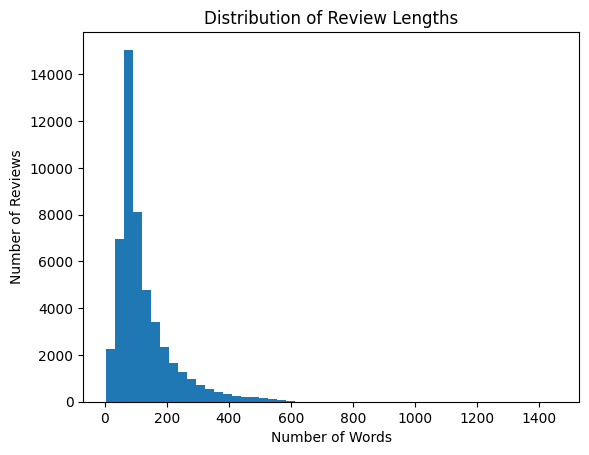

In [77]:
import matplotlib.pyplot as plt

plt.hist(sequence_lengths, bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.show()

### Analyzing The Plot
- **The Peak (Mode)**: Our most common review length is around 100 words.

- **The Outliers**: We have reviews that are 1000+ words long. If you set our `maxlen` to 1400, our **Simple RNN** will struggle because it will be trying to process hundreds of "0" (padding) values for almost every single review.

- **The "Vanishing Gradient" Problem**: **Simple RNNs** have a very short memory. If you give them a sequence that is too long (like 600+), the model will "forget" the beginning of the review by the time it reaches the end.

In [78]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Based on your histogram, 250 is the "Sweet Spot"
X = pad_sequences(sequences, maxlen=250,
                  padding='pre',      # RNNs remember the end better
                  truncating='pre'    # Keeps the 'conclusion' of long reviews
                  )

print("Shape of data tensor:", X.shape)

Shape of data tensor: (50000, 250)


In [79]:
X

array([[   0,    0,    0, ...,  417, 3367,  350],
       [   0,    0,    0, ..., 1635,   27,  144],
       [   0,    0,    0, ...,   18,    9,  259],
       ...,
       [   0,    0,    0, ...,    1,    1, 5019],
       [   0,    0,    0, ...,    1, 1791,  182],
       [   0,    0,    0, ...,  860,  590,    4]], dtype=int32)

In [80]:
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Fit and transform your labels
y = le.fit_transform(data['sentiment'])

# To see which number represents which class:
print(f"Classes: {le.classes_}")
print(f"Encoded labels: {y[:5]}")

Classes: ['negative' 'positive']
Encoded labels: [1 1 1 0 1]


In [81]:
# Save the label_encoder.pickle
with open('.models/label_encoder.pickle', 'wb') as handle:
    pickle.dump(le, handle)

# Split into train and test

In [82]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [83]:
X_train.shape

(40000, 250)

In [84]:
X_test.shape

(10000, 250)

# Train the Simple RNN

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout


max_words = 10000  # Your Tokenizer limit
max_len = 250     # Your padding limit
embedding_dim = 64 # Size of the word vectors

model = Sequential([
    # Embedding Layer: Turns word IDs into meaningful dense vectors
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_shape=(max_len,)),

    # SimpleRNN Layer: Processes the sequence
    SimpleRNN(32, activation='relu', return_sequences=False,kernel_regularizer=regularizers.l2(0.001)),

    # Dropout: Prevents overfitting
    Dropout(0.5),

    # Output Layer: Sigmoid for binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [86]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,137 (2.45 MB)

 Trainable params: 643,137 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## EarlyStopping Concept

In [88]:
from tensorflow.keras.callbacks import EarlyStopping

# Configure the monitor
early_stop = EarlyStopping(
    monitor='val_loss',      # Watch the validation loss
    mode='min',              # We want the loss to be as low as possible
    patience=10,              # Wait for 10 epochs of no improvement before stopping
    restore_best_weights=True # Very important: gives you the best version of the model
)

In [89]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,       # How many reviews the model looks at before updating weights
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7154 - loss: 0.5646 - val_accuracy: 0.8134 - val_loss: 0.4192
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8696 - loss: 0.3448 - val_accuracy: 0.8741 - val_loss: 0.3118
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8928 - loss: 0.2941 - val_accuracy: 0.8672 - val_loss: 0.3135
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9164 - loss: 0.2367 - val_accuracy: 0.8809 - val_loss: 0.3094
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.9183 - loss: 0.2292 - val_accuracy: 0.8548 - val_loss: 0.3790
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9296 - loss: 0.1989 - val_accuracy: 0.8718 - val_loss: 0.3324
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9329 - loss: 0.1939 - val_accuracy: 0.8693 - val_loss: 0.3529
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9413 - loss: 0

In [90]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8809 - loss: 0.3094
Final Test Accuracy: 88.09%


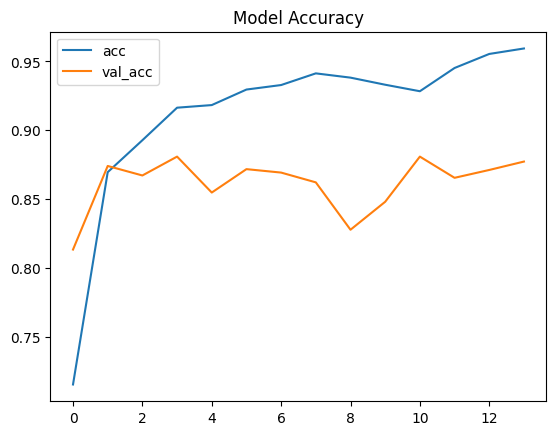

In [91]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

In [92]:
model.save('.models/sentiment_rnn_model.keras')